# Test Split Dataset Output

This notebook loads the output dataset from `split_dataset_by_skills.py` and validates it works correctly with LeRobot's `LeRobotDataset` class.


In [37]:
import sys
from pathlib import Path
import json
import yaml
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Add lerobot to path
sys.path.insert(0, str(Path.cwd() / "third_party/lerobot"))

from lerobot.common.datasets.lerobot_dataset import LeRobotDataset


## 1. Configure Paths

Set the paths to your source and output datasets.


In [22]:
# Configuration
SOURCE_DATASET = Path("/Users/sherrychen/Documents/chef_dev/ChefResearch/sandi/datasets/chef_robotics/lettuce-sandwich")
OUTPUT_DATASET = Path("/Users/sherrychen/Documents/chef_dev/ChefResearch/sandi/datasets/chef_robotics/lettuce-sandwich-skills")

# Verify paths exist
assert SOURCE_DATASET.exists(), f"Source dataset not found: {SOURCE_DATASET}"

if OUTPUT_DATASET.exists():
    print(f"✅ Output dataset found: {OUTPUT_DATASET}")
else:
    print(f"⚠️  Output dataset not found: {OUTPUT_DATASET}")
    print("Run the split script first with --max-episodes 2 for testing:")
    print(f"""python split_dataset_by_skills.py \\
  --source-root {SOURCE_DATASET} \\
  --output-root {OUTPUT_DATASET} \\
  --repo-id "chef_robotics/lettuce-sandwich" \\
  --max-episodes 2""")

✅ Output dataset found: /Users/sherrychen/Documents/chef_dev/ChefResearch/sandi/datasets/chef_robotics/lettuce-sandwich-skills


## 2. Inspect Dataset Metadata

Load and display information about the split dataset.

In [23]:
# Load info.json
with open(OUTPUT_DATASET / "meta/info.json") as f:
    info = json.load(f)

print("Dataset Info:")
print(f"  Total episodes: {info['total_episodes']}")
print(f"  Total frames: {info['total_frames']}")
print(f"  Total tasks: {info['total_tasks']}")
print(f"  FPS: {info['fps']}")
print(f"  Splits: {info['splits']}")

Dataset Info:
  Total episodes: 14
  Total frames: 2630
  Total tasks: 6
  FPS: 30
  Splits: {'train': '0:14'}


In [24]:
# Load tasks.jsonl
tasks = []
with open(OUTPUT_DATASET / "meta/tasks.jsonl") as f:
    for line in f:
        tasks.append(json.loads(line))

print(f"Tasks ({len(tasks)} total):")
for task in tasks:
    print(f"  [{task['task_index']}] {task['task']}")

Tasks (6 total):
  [0] Pick up one slice of bread.
  [1] Put one slice of bread at the blue cross mark on the table.
  [2] Pick up one piece of lettuce leaf.
  [3] Put one piece of lettuce leaf on the bread.
  [4] Put one slice of bread on the lettuce.
  [5] Go back to home position.


In [25]:
# Load episodes_metadata.jsonl (first 10)
episodes_metadata = []
with open(OUTPUT_DATASET / "meta/episodes_metadata.jsonl") as f:
    for line in f:
        episodes_metadata.append(json.loads(line))

print(f"Episodes Metadata (showing first 5 of {len(episodes_metadata)}):")
for ep in episodes_metadata[:5]:
    print(f"\nEpisode {ep['episode_index']}:")
    print(f"  Source: {ep.get('source_episode', 'N/A')}")
    print(f"  Skills: {ep.get('skills', {})}")
    for key, value in ep.items():
        if key not in ['episode_index', 'source_episode', 'skills']:
            print(f"  {key}: {value}")

Episodes Metadata (showing first 5 of 14):

Episode 0:
  Source: chef_robotics/lettuce-sandwich/26:[0.0, 11.4]
  Skills: {'pick_up_bread': [[0.0, 11.4]]}
  right_arm_helping: True

Episode 1:
  Source: chef_robotics/lettuce-sandwich/26:[24.5, 35.833333333333336]
  Skills: {'pick_up_bread': [[0.0, 11.333333333333336]]}
  right_arm_helping: True

Episode 2:
  Source: chef_robotics/lettuce-sandwich/26:[11.4, 15.4]
  Skills: {'put_bread_on_table': [[0.0, 4.0]]}
  right_arm_helping: True

Episode 3:
  Source: chef_robotics/lettuce-sandwich/26:[15.4, 21.166666666666668]
  Skills: {'pick_up_lettuce': [[0.0, 5.7666666666666675]]}
  right_arm_helping: True

Episode 4:
  Source: chef_robotics/lettuce-sandwich/26:[21.166666666666668, 24.5]
  Skills: {'put_lettuce_on_bread': [[0.0, 3.333333333333332]]}
  right_arm_helping: True


In [41]:
# Load episodes_stats.jsonl
episodes_stats = []
with open(OUTPUT_DATASET / "meta/episodes_stats.jsonl") as f:
    for line in f:
        episodes_stats.append(json.loads(line))

print(f"✅ Loaded {len(episodes_stats)} episode statistics")
print(f"   First episode has stats for: {list(episodes_stats[0]['stats'].keys())}")



✅ Loaded 805 episode statistics
   First episode has stats for: ['action', 'observation.state', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index']


In [42]:
# Aggregate min/max/mean across all episodes for actions and observations
def aggregate_joint_stats(episodes_stats, stat_key='action'):
    """
    Aggregate joint statistics across all episodes.
    
    Args:
        episodes_stats: List of episode statistics
        stat_key: Either 'action' or 'observation.state'
    
    Returns:
        dict with aggregated min, max, mean for each joint
    """
    all_mins = []
    all_maxs = []
    all_means = []
    
    for ep_stat in episodes_stats:
        if stat_key in ep_stat['stats']:
            all_mins.append(ep_stat['stats'][stat_key]['min'])
            all_maxs.append(ep_stat['stats'][stat_key]['max'])
            all_means.append(ep_stat['stats'][stat_key]['mean'])
    
    # Convert to numpy arrays for easier computation
    all_mins = np.array(all_mins)
    all_maxs = np.array(all_maxs)
    all_means = np.array(all_means)
    
    # Aggregate across episodes
    aggregated = {
        'min': np.min(all_mins, axis=0),  # Take minimum of all episode minimums
        'max': np.max(all_maxs, axis=0),  # Take maximum of all episode maximums
        'mean': np.mean(all_means, axis=0)  # Take average of all episode means
    }
    
    return aggregated

# Aggregate for actions
action_stats = aggregate_joint_stats(episodes_stats, 'action')
print("Action Joint Statistics (aggregated across all episodes):")
print(f"  Number of joints: {len(action_stats['min'])}")
print(f"  Min range: [{action_stats['min'].min():.4f}, {action_stats['min'].max():.4f}]")
print(f"  Max range: [{action_stats['max'].min():.4f}, {action_stats['max'].max():.4f}]")
print(f"  Mean range: [{action_stats['mean'].min():.4f}, {action_stats['mean'].max():.4f}]")

print("\n" + "="*60 + "\n")

# Aggregate for observation states
state_stats = aggregate_joint_stats(episodes_stats, 'observation.state')
print("Observation State Joint Statistics (aggregated across all episodes):")
print(f"  Number of joints: {len(state_stats['min'])}")
print(f"  Min range: [{state_stats['min'].min():.4f}, {state_stats['min'].max():.4f}]")
print(f"  Max range: [{state_stats['max'].min():.4f}, {state_stats['max'].max():.4f}]")
print(f"  Mean range: [{state_stats['mean'].min():.4f}, {state_stats['mean'].max():.4f}]")


Action Joint Statistics (aggregated across all episodes):
  Number of joints: 14
  Min range: [-2.2482, 0.6758]
  Max range: [0.0238, 2.2452]
  Mean range: [-0.9797, 1.4668]


Observation State Joint Statistics (aggregated across all episodes):
  Number of joints: 14
  Min range: [-2.2471, 0.6750]
  Max range: [0.0238, 2.2448]
  Mean range: [-0.9823, 1.4674]


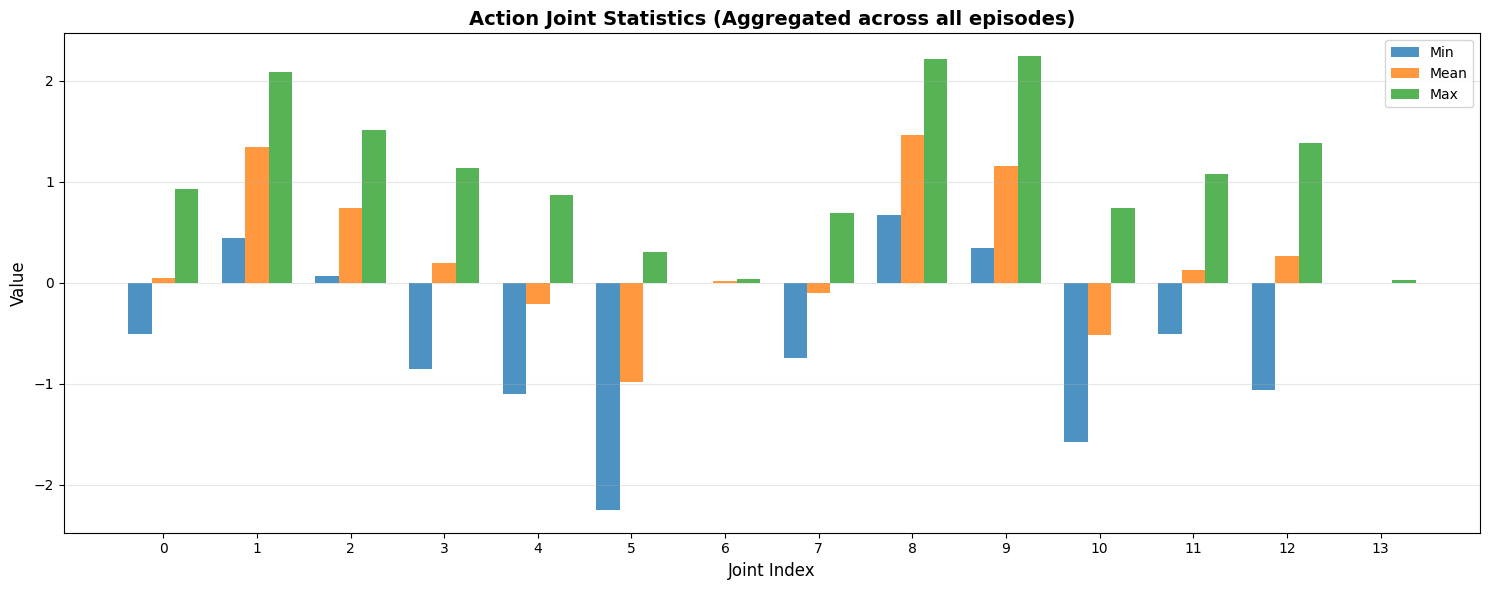

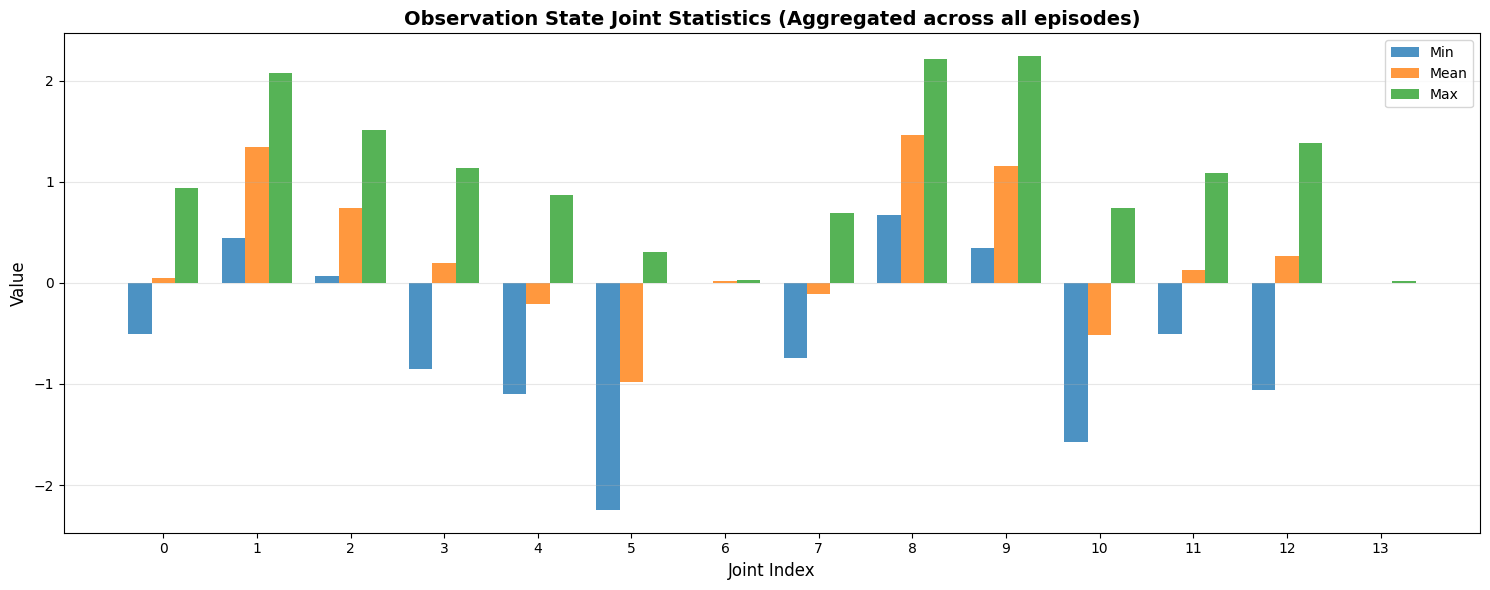

In [43]:
# Plot aggregated joint statistics
def plot_joint_stats(stats, title, joint_names=None):
    """
    Plot min, max, and mean for all joints.
    
    Args:
        stats: Dictionary with 'min', 'max', 'mean' arrays
        title: Title for the plot
        joint_names: Optional list of joint names
    """
    num_joints = len(stats['min'])
    if joint_names is None:
        joint_names = [f'Joint {i}' for i in range(num_joints)]
    
    x = np.arange(num_joints)
    width = 0.25
    
    fig, ax = plt.subplots(figsize=(15, 6))
    
    # Plot bars
    bars1 = ax.bar(x - width, stats['min'], width, label='Min', alpha=0.8)
    bars2 = ax.bar(x, stats['mean'], width, label='Mean', alpha=0.8)
    bars3 = ax.bar(x + width, stats['max'], width, label='Max', alpha=0.8)
    
    ax.set_xlabel('Joint Index', fontsize=12)
    ax.set_ylabel('Value', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(range(num_joints))
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Plot action statistics
plot_joint_stats(
    action_stats, 
    'Action Joint Statistics (Aggregated across all episodes)'
)

# Plot observation state statistics
plot_joint_stats(
    state_stats, 
    'Observation State Joint Statistics (Aggregated across all episodes)'
)


## 3. Load Dataset with LeRobotDataset

Load the dataset using LeRobot's dataset class and test `__getitem__()`.

In [38]:
root = "/Users/sherrychen/Documents/chef_dev/ChefResearch/sandi/datasets/chef_robotics/lettuce-sandwich-skills"
repo_id = "chef_robotics/lettuce-sandwich-skills"

# Load the dataset
dataset = LeRobotDataset(
    repo_id=repo_id, 
    root=root,
    video_backend="pyav",
)

print(f"✅ Dataset loaded successfully!")
print(f"   Total frames in dataset: {len(dataset)}")
print(f"   Number of episodes: {dataset.num_episodes}")
print(f"   FPS: {dataset.fps}")

✅ Dataset loaded successfully!
   Total frames in dataset: 149432
   Number of episodes: 805
   FPS: 30


In [32]:
item = dataset[683]

/Users/sherrychen/Documents/chef_dev/ChefResearch/sandi/.venv/lib/python3.10/site-packages/torchvision/io/_video_deprecation_warning.py:9: UserWarning: The video decoding and encoding capabilities of torchvision are deprecated from version 0.22 and will be removed in version 0.24. We recommend that you migrate to TorchCodec, where we'll consolidate the future decoding/encoding capabilities of PyTorch: https://github.com/pytorch/torchcodec
  warnings.warn(


## 4. Load Original Dataset for Comparison

Load the source dataset to compare with the split dataset.

In [27]:
source_root = "/Users/sherrychen/Documents/chef_dev/ChefResearch/sandi/datasets/chef_robotics/lettuce-sandwich"
source_repo_id = "chef_robotics/lettuce-sandwich"
# Load the original source dataset
source_dataset = LeRobotDataset(
    repo_id=source_repo_id,
    root=source_root,
    video_backend="pyav",
)

print(f"✅ Source dataset loaded!")
print(f"   Total frames: {len(source_dataset)}")
print(f"   Number of episodes: {source_dataset.num_episodes}")
print()

print(f"📊 Comparison:")
print(f"   Source: {len(source_dataset)} frames, {source_dataset.num_episodes} episodes")
print(f"   Split:  {len(dataset)} frames, {dataset.num_episodes} episodes")

✅ Source dataset loaded!
   Total frames: 211981
   Number of episodes: 169

📊 Comparison:
   Source: 211981 frames, 169 episodes
   Split:  2630 frames, 14 episodes


In [28]:
# Helper function to find corresponding source frame
def find_source_frame(split_item, episodes_metadata):
    """
    Find the corresponding frame in the source dataset.
    
    Returns:
        source_episode_idx, source_frame_idx (or None if not found)
    """
    split_ep_idx = split_item['episode_index'].item()
    split_frame_idx = split_item['frame_index'].item()
    
    # Get the episode metadata
    ep_meta = episodes_metadata[split_ep_idx]
    source_info = ep_meta.get('source_episode', '')
    
    # Parse: "repo_id/episode_index:[start_time, end_time]"
    if '/' in source_info and ':' in source_info:
        parts = source_info.split('/')
        ep_and_time = parts[-1].split(':')
        source_ep_idx = int(ep_and_time[0])
        
        # Parse time interval
        time_str = ep_and_time[1].strip('[]')
        start_time = float(time_str.split(',')[0])
        
        # Calculate source frame index
        # Split episode starts at frame 0, which corresponds to start_time in source
        source_frame_idx = int(start_time * dataset.fps) + split_frame_idx
        
        return source_ep_idx, source_frame_idx
    
    return None, None

print("Helper function created to find corresponding source frames")

Helper function created to find corresponding source frames


## 5. Compare Split vs Source Data

Compare entries from the split dataset with the original source dataset.


In [ ]:
# THIS DOES NOT WORK
# Test a few items and compare with source
test_indices = [0]

for split_idx in test_indices:
    if split_idx >= len(dataset):
        continue
    
    # Get item from split dataset
    split_item = dataset[split_idx]
    
    # Find corresponding source frame
    source_ep_idx, source_frame_idx = find_source_frame(split_item, episodes_metadata)
    
    if source_ep_idx is not None:
        # Find the source frame index in the flat dataset
        source_flat_idx = None
        for idx in range(len(source_dataset)):
            item = source_dataset[idx]
            if (item['episode_index'].item() == source_ep_idx and 
                item['frame_index'].item() == source_frame_idx):
                source_flat_idx = idx
                break
        
        if source_flat_idx is not None:
            source_item = source_dataset[source_flat_idx]
            
            print(f"\n{'='*60}")
            print(f"Split index {split_idx}:")
            print(f"  Split episode: {split_item['episode_index'].item()}, frame: {split_item['frame_index'].item()}")
            print(f"  Source episode: {source_ep_idx}, frame: {source_frame_idx} (flat index: {source_flat_idx})")
            print(f"  Task index: split={split_item['task_index'].item()}, source={source_item['task_index'].item()}")
            
            # Compare actions
            action_match = torch.allclose(split_item['action'], source_item['action'], rtol=1e-5)
            print(f"  Actions match: {action_match} ✅" if action_match else f"  Actions match: {action_match} ❌")
            
            # Compare states
            state_match = torch.allclose(split_item['observation.state'], source_item['observation.state'], rtol=1e-5)
            print(f"  States match: {state_match} ✅" if state_match else f"  States match: {state_match} ❌")
            
            # Compare timestamps (should be different - split starts at 0)
            print(f"  Timestamp: split={split_item['timestamp'].item():.4f}, source={source_item['timestamp'].item():.4f}")
        else:
            print(f"\nCouldn't find source frame for split index {split_idx}")
    else:
        print(f"\nCouldn't parse source info for split index {split_idx}")


KeyboardInterrupt: 

In [33]:
# Compare images from split vs source
split_idx = 10  # Change this to test different frames
split_item = dataset[split_idx]

# Find corresponding source frame
source_ep_idx, source_frame_idx = find_source_frame(split_item, episodes_metadata)

if source_ep_idx is not None:
    # Find source item
    source_flat_idx = None
    for idx in range(len(source_dataset)):
        item = source_dataset[idx]
        if (item['episode_index'].item() == source_ep_idx and 
            item['frame_index'].item() == source_frame_idx):
            source_flat_idx = idx
            break
    
    if source_flat_idx is not None:
        source_item = source_dataset[source_flat_idx]
        
        # Find all image keys
        image_keys = [key for key in split_item.keys() if 'observation.images' in key]
        
        if len(image_keys) > 0:
            # Show first camera only for comparison
            img_key = image_keys[0]
            
            fig, axes = plt.subplots(1, 2, figsize=(12, 5))
            
            # Split dataset image
            split_img = split_item[img_key]
            if isinstance(split_img, torch.Tensor):
                split_img = split_img.numpy()
            if split_img.shape[0] == 3:
                split_img = np.transpose(split_img, (1, 2, 0))
            if split_img.dtype in [np.float32, np.float64]:
                split_img = (split_img * 255).astype(np.uint8)
            
            # Source dataset image
            source_img = source_item[img_key]
            if isinstance(source_img, torch.Tensor):
                source_img = source_img.numpy()
            if source_img.shape[0] == 3:
                source_img = np.transpose(source_img, (1, 2, 0))
            if source_img.dtype in [np.float32, np.float64]:
                source_img = (source_img * 255).astype(np.uint8)
            
            axes[0].imshow(split_img)
            axes[0].set_title(f'Split Dataset\nIndex {split_idx} (ep {split_item["episode_index"].item()}, frame {split_item["frame_index"].item()})')
            axes[0].axis('off')
            
            axes[1].imshow(source_img)
            axes[1].set_title(f'Source Dataset\nIndex {source_flat_idx} (ep {source_ep_idx}, frame {source_frame_idx})')
            axes[1].axis('off')
            
            plt.tight_layout()
            plt.show()
            
            # Check if images are identical
            images_match = np.allclose(split_img, source_img, rtol=1e-3)
            print(f"Images match: {images_match} {'✅' if images_match else '❌'}")
        else:
            print("No images found")
    else:
        print("Couldn't find source frame")
else:
    print("Couldn't parse source info")


KeyboardInterrupt: 

## 7. Visualize Split Dataset Images

Display all camera views from the split dataset.

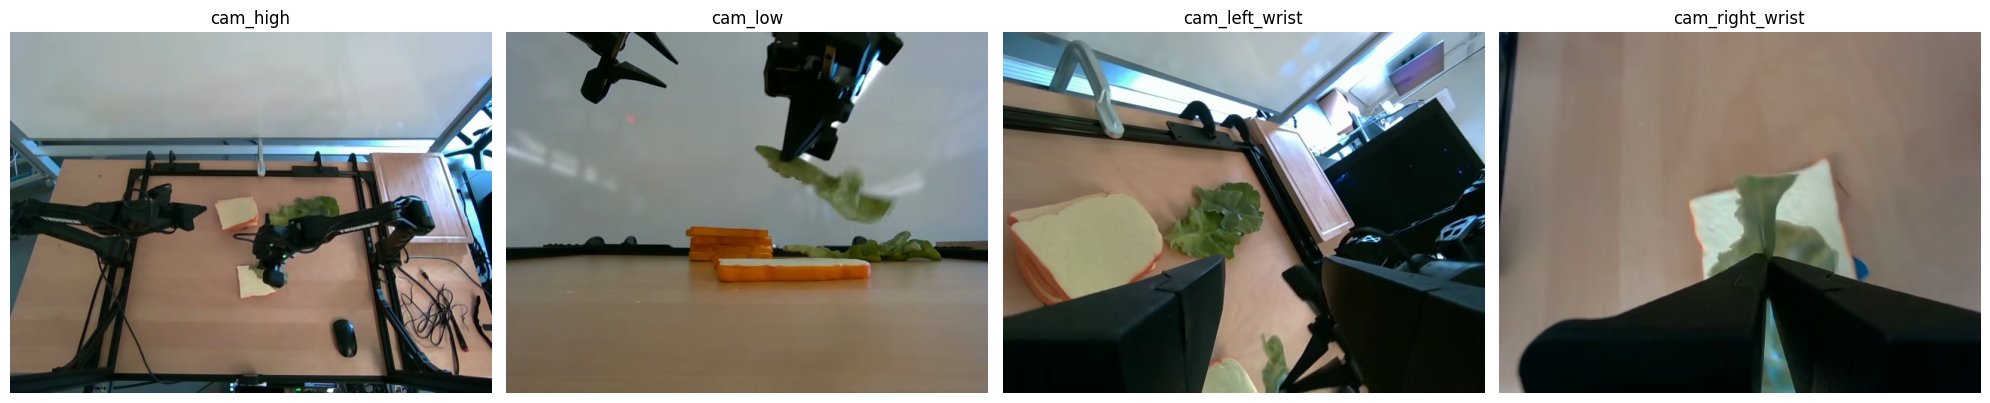

✅ Displayed 4 camera views


In [35]:
# Get an item
item = dataset[1002]

# Find all image keys
image_keys = [key for key in item.keys() if 'observation.images' in key]

if len(image_keys) > 0:
    # Create subplots
    fig, axes = plt.subplots(1, min(len(image_keys), 4), figsize=(20, 5))
    if len(image_keys) == 1:
        axes = [axes]
    
    for idx, image_key in enumerate(image_keys[:4]):
        img = item[image_key]
        if isinstance(img, torch.Tensor):
            img = img.numpy()
        
        # Convert CHW to HWC if needed
        if img.shape[0] == 3:
            img = np.transpose(img, (1, 2, 0))
        
        # Convert to uint8 if needed
        if img.dtype in [np.float32, np.float64]:
            img = (img * 255).astype(np.uint8)
        
        axes[idx].imshow(img)
        axes[idx].set_title(image_key.replace('observation.images.', ''))
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()
    print(f"✅ Displayed {len(image_keys)} camera views")
else:
    print("No images found")

## 8. Test Batch Loading with DataLoader

Test loading batches of data for training.

In [36]:
from torch.utils.data import DataLoader

# Create DataLoader
batch_size = 4
dataloader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

# Get one batch
batch = next(iter(dataloader))

print(f"Batch with {batch_size} samples:")
for key in sorted(batch.keys()):
    value = batch[key]
    if isinstance(value, torch.Tensor):
        print(f"  {key}: shape {value.shape}, dtype {value.dtype}")

print(f"\n✅ Batch loading works!")

Batch with 4 samples:
  action: shape torch.Size([4, 14]), dtype torch.float32
  episode_index: shape torch.Size([4]), dtype torch.int64
  frame_index: shape torch.Size([4]), dtype torch.int64
  index: shape torch.Size([4]), dtype torch.int64
  observation.images.cam_high: shape torch.Size([4, 3, 480, 640]), dtype torch.float32
  observation.images.cam_left_wrist: shape torch.Size([4, 3, 480, 640]), dtype torch.float32
  observation.images.cam_low: shape torch.Size([4, 3, 480, 640]), dtype torch.float32
  observation.images.cam_right_wrist: shape torch.Size([4, 3, 480, 640]), dtype torch.float32
  observation.state: shape torch.Size([4, 14]), dtype torch.float32
  task_index: shape torch.Size([4]), dtype torch.int64
  timestamp: shape torch.Size([4]), dtype torch.float32

✅ Batch loading works!


## 9. Summary

Final validation summary.

In [ ]:
print("=" * 80)
print("DATASET VALIDATION SUMMARY")
print("=" * 80)
print(f"✅ Dataset loads with LeRobotDataset")
print(f"✅ __getitem__() works correctly")
print(f"✅ Episodes: {dataset.num_episodes}")
print(f"✅ Total frames: {len(dataset)}")
print(f"✅ Tasks: {len(tasks)}")
print(f"✅ Image observations: {len(image_keys)} cameras")
print(f"✅ Batch loading works")
print("=" * 80)
print("\n🎉 Split dataset is ready for training!")